# Bayer Leverkusen 2023/24: Pressing analysis

## Question

How often did Leverkusen regain the ball quickly after applying pressure, and did those regains create more attacking value than other open-play possessions starting in similar areas?

The notebook uses StatsBomb event data from all 34 Bundesliga matches in Leverkusen's 2023/24 season. The analysis separates the pressure event, the regain and the attacking outcome that follows.

## Definitions

One row represents one **pressured opposition possession**, rather than one pressure event.

- **Representative pressure:** the final Leverkusen pressure in the opposition possession.
- **Quick regain:** Leverkusen begin the next possession within 5 seconds, with no opposition shot before the change.
- **Shot-producing regain:** Leverkusen take a shot within the first 15 seconds of the regained possession.
- **Location-matched baseline:** ordinary Leverkusen open-play possessions beginning in the same pitch third and lateral channel.
- **Censored sequence:** the period ends before the full 5-second window can be observed. These sequences are excluded from rate calculations.

The time windows are parameters in the first code cell and can be changed.

In [1]:
from IPython.display import Markdown, display
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mplsoccer import Pitch, Sbopen

TEAM = "Bayer Leverkusen"
COMPETITION_ID = 9
SEASON_ID = 281
REGAIN_WINDOW_SECONDS = 5
SHOT_WINDOW_SECONDS = 15

LEVERKUSEN_RED = "#e32219"
LEVERKUSEN_DARK = "#171717"
SUCCESS_BLUE = "#277da1"
SHOT_GOLD = "#f2b134"
LIGHT_GREY = "#d8d8d8"

pd.set_option("display.max_columns", 30)
parser = Sbopen()

## 1. Load the season

The competition and season IDs select Leverkusen's 34 Bundesliga matches. The match list is sorted by date before the event data is loaded.

In [2]:
matches = parser.match(
    competition_id=COMPETITION_ID,
    season_id=SEASON_ID,
)

team_matches = (
    matches.loc[
        matches["home_team_name"].eq(TEAM)
        | matches["away_team_name"].eq(TEAM)
    ]
    .sort_values(["match_date", "match_id"])
    .reset_index(drop=True)
)

assert len(team_matches) == 34, (
    f"Expected 34 Bundesliga matches, found {len(team_matches)}. "
    "Check the competition/season IDs or the upstream data."
)

team_matches[
    [
        "match_id",
        "match_date",
        "home_team_name",
        "away_team_name",
        "home_score",
        "away_score",
    ]
]

,match_id,match_date,home_team_name,away_team_name,home_score,away_score
0,3895052,2023-08-19,Bayer Leverkusen,RB Leipzig,3,2
1,3895060,2023-08-26,Borussia Mönchengladbach,Bayer Leverkusen,0,3
2,3895067,2023-09-02,Bayer Leverkusen,Darmstadt 98,5,1
3,3895074,2023-09-15,Bayern Munich,Bayer Leverkusen,2,2
4,3895086,2023-09-24,Bayer Leverkusen,FC Heidenheim,4,1
5,3895095,2023-09-30,FSV Mainz 05,Bayer Leverkusen,0,3
6,3895107,2023-10-08,Bayer Leverkusen,FC Köln,3,0
7,3895113,2023-10-21,Wolfsburg,Bayer Leverkusen,1,2
8,3895121,2023-10-29,Bayer Leverkusen,Freiburg,2,1
9,3895134,2023-11-04,Hoffenheim,Bayer Leverkusen,2,3


In [3]:
event_frames = []

for match_id in team_matches["match_id"]:
    match_events, _, _, _ = parser.event(match_id)
    event_frames.append(match_events.assign(match_id=int(match_id)))

season_events = (
    pd.concat(event_frames, ignore_index=True)
    .sort_values(["match_id", "period", "index"])
    .reset_index(drop=True)
)

required_columns = {
    "match_id",
    "period",
    "index",
    "minute",
    "second",
    "possession",
    "possession_team_name",
    "team_name",
    "player_name",
    "type_name",
    "x",
    "y",
    "counterpress",
    "shot_statsbomb_xg",
    "outcome_name",
    "sub_type_name",
    "end_x",
    "end_y",
}
missing_columns = required_columns.difference(season_events.columns)
assert not missing_columns, f"Missing expected event columns: {sorted(missing_columns)}"

season_events["time_seconds"] = (
    season_events["minute"].mul(60).add(season_events["second"])
)

pd.Series(
    {
        "Matches": team_matches["match_id"].nunique(),
        "Events": len(season_events),
        "Leverkusen pressure events": (
            season_events["team_name"].eq(TEAM)
            & season_events["type_name"].eq("Pressure")
        ).sum(),
    },
    name="data check",
).to_frame()

,data check
Matches,34
Events,137765
Leverkusen pressure events,4786


## 2. Build one record per pressured possession

A pressure is included when Leverkusen apply it during an opposition possession. The final pressure represents the sequence, and pressures too close to the end of a period are marked as censored rather than dropped.

In [4]:
opposition_pressures = season_events.loc[
    season_events["team_name"].eq(TEAM)
    & season_events["type_name"].eq("Pressure")
    & season_events["possession_team_name"].ne(TEAM)
].copy()

last_pressures = (
    opposition_pressures
    .groupby(["match_id", "period", "possession"], sort=False, as_index=False)
    .tail(1)
    .sort_values(["match_id", "period", "index"])
    .reset_index(drop=True)
)

match_periods = {
    key: frame
    for key, frame in season_events.groupby(["match_id", "period"], sort=False)
}

sequence_records = []

for pressure in last_pressures.itertuples(index=False):
    period_events = match_periods[(pressure.match_id, pressure.period)]
    period_end_time = period_events["time_seconds"].max()

    later_events = period_events.loc[period_events["index"].gt(pressure.index)]
    changed_possession = later_events.loc[
        later_events["possession"].ne(pressure.possession)
    ]

    next_event = None if changed_possession.empty else changed_possession.iloc[0]
    time_to_next_possession = np.nan
    next_possession = np.nan
    next_possession_team = None
    opponent_shot_before_change = False
    observation_complete = True

    if next_event is None:
        # Exclude only cases where the period ends before all five seconds can be observed.
        observation_complete = (
            period_end_time - pressure.time_seconds >= REGAIN_WINDOW_SECONDS
        )
    else:
        time_to_next_possession = (
            next_event["time_seconds"] - pressure.time_seconds
        )
        next_possession = next_event["possession"]
        next_possession_team = next_event["possession_team_name"]

        between = period_events.loc[
            period_events["index"].gt(pressure.index)
            & period_events["index"].lt(next_event["index"])
        ]
        opponent_shot_before_change = (
            between["type_name"].eq("Shot")
            & between["team_name"].ne(TEAM)
        ).any()

    regained_within_5s = bool(
        observation_complete
        and next_event is not None
        and next_possession_team == TEAM
        and 0 <= time_to_next_possession <= REGAIN_WINDOW_SECONDS
        and not opponent_shot_before_change
    )

    shot_within_15s = False
    shot_count = 0
    shot_xg = 0.0
    goal_after_regain = False

    if regained_within_5s:
        regained_events = period_events.loc[
            period_events["possession"].eq(next_possession)
            & period_events["index"].ge(next_event["index"])
            & period_events["team_name"].eq(TEAM)
        ]
        quick_shots = regained_events.loc[
            regained_events["type_name"].eq("Shot")
            & regained_events["time_seconds"].sub(next_event["time_seconds"]).between(
                0, SHOT_WINDOW_SECONDS
            )
        ]
        shot_count = len(quick_shots)
        shot_within_15s = shot_count > 0
        shot_xg = quick_shots["shot_statsbomb_xg"].fillna(0).sum()
        goal_after_regain = quick_shots["outcome_name"].eq("Goal").any()

    sequence_records.append(
        {
            "match_id": pressure.match_id,
            "period": pressure.period,
            "opposition_possession": pressure.possession,
            "pressure_event_index": pressure.index,
            "pressure_minute": pressure.minute,
            "pressure_player": pressure.player_name,
            "pressure_x": pressure.x,
            "pressure_y": pressure.y,
            "is_counterpress": bool(pd.notna(pressure.counterpress)),
            "observation_complete": bool(observation_complete),
            "time_to_next_possession": time_to_next_possession,
            "next_possession": next_possession,
            "next_possession_team": next_possession_team,
            "opponent_shot_before_change": bool(opponent_shot_before_change),
            "regained_within_5s": regained_within_5s,
            "shot_within_15s": shot_within_15s,
            "shot_count": shot_count,
            "shot_xg": shot_xg,
            "goal_after_regain": bool(goal_after_regain),
        }
    )

pressure_sequences = pd.DataFrame(sequence_records)
pressure_sequences["pressure_zone"] = pd.cut(
    pressure_sequences["pressure_x"],
    bins=[0, 40, 80, 120],
    labels=["Defensive third", "Middle third", "Attacking third"],
    include_lowest=True,
)

analysis_sequences = pressure_sequences.loc[
    pressure_sequences["observation_complete"]
].copy()

assert not pressure_sequences.duplicated(
    ["match_id", "period", "opposition_possession"]
).any()
assert analysis_sequences.loc[
    analysis_sequences["regained_within_5s"], "time_to_next_possession"
].between(0, REGAIN_WINDOW_SECONDS).all()

pd.Series(
    {
        "Pressure events in opposition possessions": len(opposition_pressures),
        "Distinct pressured opposition possessions": len(pressure_sequences),
        "Censored at period end": (~pressure_sequences["observation_complete"]).sum(),
        "Possessions included in rates": len(analysis_sequences),
    },
    name="sequence check",
).to_frame()

,sequence check
Pressure events in opposition possessions,3964
Distinct pressured opposition possessions,1707
Censored at period end,5
Possessions included in rates,1702


## 3. Season summary

The regain rate uses all fully observed pressured possessions as its denominator. The shot rate uses successful quick regains as its denominator.

In [5]:
total_sequences = len(analysis_sequences)
successful_regains = int(analysis_sequences["regained_within_5s"].sum())
shot_sequences = int(analysis_sequences["shot_within_15s"].sum())
goals_after_regain = int(analysis_sequences["goal_after_regain"].sum())

season_summary = pd.DataFrame(
    {
        "Metric": [
            "Fully observed pressured possessions",
            f"Regained within {REGAIN_WINDOW_SECONDS} seconds",
            f"Shot within {SHOT_WINDOW_SECONDS} seconds of quick regain",
            "Goals from those shots",
            "Regain rate",
            "Shot rate per quick regain",
        ],
        "Value": [
            f"{total_sequences:,}",
            f"{successful_regains:,}",
            f"{shot_sequences:,}",
            f"{goals_after_regain:,}",
            f"{successful_regains / total_sequences:.1%}",
            f"{shot_sequences / successful_regains:.1%}",
        ],
    }
)

season_summary

,Metric,Value
0,Fully observed pressured possessions,"1,702"
1,Regained within 5 seconds,538
2,Shot within 15 seconds of quick regain,46
3,Goals from those shots,4
4,Regain rate,31.6%
5,Shot rate per quick regain,8.6%


## 4. Compare quick regains with possessions from similar areas

High regains begin closer to goal, so comparing them with every Leverkusen possession would exaggerate their value. Each quick regain is instead compared with ordinary open-play possessions starting in the same coarse pitch area.

The pitch is divided into nine cells: three length bands and three lateral channels. Cells with fewer than 30 baseline possessions are excluded from the matched comparison.

In [6]:
RESTART_TYPES = {"Kick Off", "Free Kick", "Corner", "Throw-in", "Goal Kick"}
PENALTY_AREA_X = 102
PENALTY_AREA_Y_MIN = 18
PENALTY_AREA_Y_MAX = 62

possession_records = []
leverkusen_possession_events = season_events.loc[
    season_events["possession_team_name"].eq(TEAM)
]

for (match_id, period, possession), possession_events in (
    leverkusen_possession_events.groupby(
        ["match_id", "period", "possession"], sort=False
    )
):
    possession_events = possession_events.sort_values("index")
    team_events = possession_events.loc[possession_events["team_name"].eq(TEAM)]
    located_team_events = team_events.dropna(subset=["x", "y"])

    if located_team_events.empty:
        continue

    first_team_event = located_team_events.iloc[0]
    possession_start_time = possession_events["time_seconds"].min()
    window_events = team_events.loc[
        team_events["time_seconds"].sub(possession_start_time).between(
            0, SHOT_WINDOW_SECONDS
        )
    ]
    window_shots = window_events.loc[window_events["type_name"].eq("Shot")]

    event_in_box = (
        window_events["x"].ge(PENALTY_AREA_X)
        & window_events["y"].between(PENALTY_AREA_Y_MIN, PENALTY_AREA_Y_MAX)
    )
    event_ends_in_box = (
        window_events["end_x"].ge(PENALTY_AREA_X)
        & window_events["end_y"].between(PENALTY_AREA_Y_MIN, PENALTY_AREA_Y_MAX)
    )

    possession_records.append(
        {
            "match_id": match_id,
            "period": period,
            "possession": possession,
            "start_time": possession_start_time,
            "start_x": first_team_event["x"],
            "start_y": first_team_event["y"],
            "start_event_type": first_team_event["type_name"],
            "start_sub_type": first_team_event["sub_type_name"],
            "open_play_start": first_team_event["sub_type_name"] not in RESTART_TYPES,
            "reached_box_within_15s": bool(event_in_box.any() or event_ends_in_box.any()),
            "shot_within_15s": bool(len(window_shots)),
            "shots_within_15s": len(window_shots),
            "xg_within_15s": window_shots["shot_statsbomb_xg"].fillna(0).sum(),
        }
    )

team_possessions = pd.DataFrame(possession_records)

quick_regain_keys = (
    analysis_sequences.loc[
        analysis_sequences["regained_within_5s"],
        ["match_id", "period", "next_possession"],
    ]
    .rename(columns={"next_possession": "possession"})
    .drop_duplicates()
    .assign(is_quick_regain=True)
)

team_possessions = team_possessions.merge(
    quick_regain_keys,
    on=["match_id", "period", "possession"],
    how="left",
    validate="one_to_one",
)
team_possessions["is_quick_regain"] = (
    team_possessions["is_quick_regain"].eq(True)
)

team_possessions["x_band"] = pd.cut(
    team_possessions["start_x"],
    bins=[0, 40, 80, 120],
    labels=False,
    include_lowest=True,
)
team_possessions["y_band"] = pd.cut(
    team_possessions["start_y"],
    bins=[0, 80 / 3, 160 / 3, 80],
    labels=False,
    include_lowest=True,
)
team_possessions["spatial_cell"] = (
    team_possessions["x_band"].astype("Int64").mul(3)
    + team_possessions["y_band"].astype("Int64")
)

ordinary_open_play = team_possessions.loc[
    team_possessions["open_play_start"]
    & ~team_possessions["is_quick_regain"]
].copy()
quick_regain_possessions = team_possessions.loc[
    team_possessions["open_play_start"]
    & team_possessions["is_quick_regain"]
].copy()

baseline_by_cell = (
    ordinary_open_play
    .groupby("spatial_cell")
    .agg(
        baseline_possessions=("match_id", "size"),
        expected_box_rate=("reached_box_within_15s", "mean"),
        expected_shot_rate=("shot_within_15s", "mean"),
        expected_xg=("xg_within_15s", "mean"),
    )
)

matched_quick_regains = quick_regain_possessions.merge(
    baseline_by_cell,
    on="spatial_cell",
    how="left",
    validate="many_to_one",
)
matched_quick_regains = matched_quick_regains.loc[
    matched_quick_regains["baseline_possessions"].ge(30)
].copy()

pd.Series(
    {
        "All Leverkusen possessions with a start location": len(team_possessions),
        "Ordinary open-play baseline possessions": len(ordinary_open_play),
        "Quick-regain possessions found": len(quick_regain_possessions),
        "Quick regains retained after matching": len(matched_quick_regains),
        "Matching cells represented": matched_quick_regains["spatial_cell"].nunique(),
    },
    name="matching audit",
).to_frame()

,matching audit
All Leverkusen possessions with a start location,2852
Ordinary open-play baseline possessions,889
Quick-regain possessions found,528
Quick regains retained after matching,489
Matching cells represented,6


In [7]:
def bootstrap_difference(
    frame,
    observed_column,
    expected_column,
    repetitions=5_000,
    seed=2024,
):
    '''Bootstrap the observed-minus-matched-expected difference.'''
    observed = frame[observed_column].to_numpy(dtype=float)
    expected = frame[expected_column].to_numpy(dtype=float)
    rng = np.random.default_rng(seed)
    samples = rng.integers(0, len(frame), size=(repetitions, len(frame)))
    differences = observed[samples].mean(axis=1) - expected[samples].mean(axis=1)
    return np.quantile(differences, [0.025, 0.975])


matched_metric_definitions = [
    (
        "Reached penalty area within 15s",
        "reached_box_within_15s",
        "expected_box_rate",
        "rate",
    ),
    ("Shot within 15s", "shot_within_15s", "expected_shot_rate", "rate"),
    ("xG within 15s", "xg_within_15s", "expected_xg", "xg"),
]

matched_rows = []
for metric, observed_column, expected_column, metric_type in matched_metric_definitions:
    observed = matched_quick_regains[observed_column].mean()
    expected = matched_quick_regains[expected_column].mean()
    ci_low, ci_high = bootstrap_difference(
        matched_quick_regains,
        observed_column,
        expected_column,
    )
    matched_rows.append(
        {
            "metric": metric,
            "metric_type": metric_type,
            "observed": observed,
            "matched_expected": expected,
            "difference": observed - expected,
            "ci_low": ci_low,
            "ci_high": ci_high,
        }
    )

matched_results = pd.DataFrame(matched_rows).set_index("metric")

matched_display_rows = []
for metric, row in matched_results.iterrows():
    if row["metric_type"] == "rate":
        observed = f"{row['observed']:.1%}"
        expected = f"{row['matched_expected']:.1%}"
        difference = f"{row['difference'] * 100:+.1f} pp"
        interval = f"[{row['ci_low'] * 100:+.1f}, {row['ci_high'] * 100:+.1f}] pp"
    else:
        observed = f"{row['observed'] * 100:.2f} per 100"
        expected = f"{row['matched_expected'] * 100:.2f} per 100"
        difference = f"{row['difference'] * 100:+.2f} per 100"
        interval = f"[{row['ci_low'] * 100:+.2f}, {row['ci_high'] * 100:+.2f}]"

    matched_display_rows.append(
        {
            "Outcome": metric,
            "Quick regains": observed,
            "Location-matched expectation": expected,
            "Difference": difference,
            "Bootstrap 95% interval": interval,
        }
    )

pd.DataFrame(matched_display_rows)

,Outcome,Quick regains,Location-matched expectation,Difference,Bootstrap 95% interval
0,Reached penalty area within 15s,15.3%,14.9%,+0.4 pp,"[-2.7, +3.7] pp"
1,Shot within 15s,6.7%,5.0%,+1.8 pp,"[-0.4, +4.0] pp"
2,xG within 15s,1.22 per 100,0.65 per 100,+0.57 per 100,"[-0.02, +1.32]"


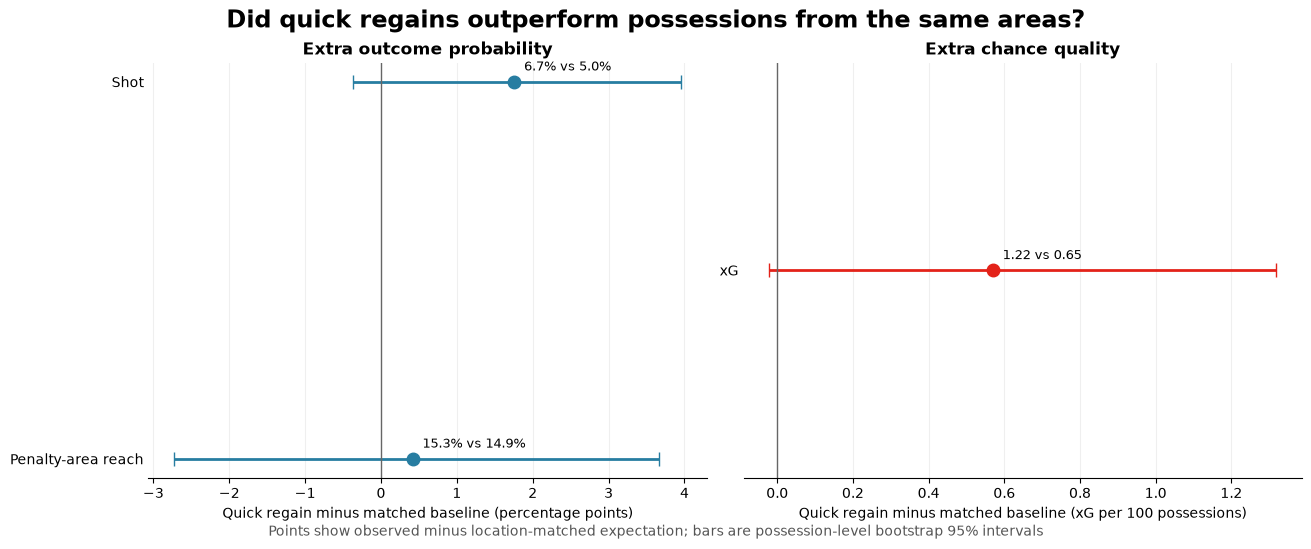

In [8]:
rate_results = matched_results.loc[
    ["Reached penalty area within 15s", "Shot within 15s"]
]
xg_result = matched_results.loc["xG within 15s"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), constrained_layout=True)

rate_y = np.arange(len(rate_results))
rate_difference = rate_results["difference"].mul(100)
rate_xerr = np.vstack(
    [
        (rate_results["difference"] - rate_results["ci_low"]).mul(100),
        (rate_results["ci_high"] - rate_results["difference"]).mul(100),
    ]
)
axes[0].errorbar(
    rate_difference,
    rate_y,
    xerr=rate_xerr,
    fmt="o",
    color=SUCCESS_BLUE,
    ecolor=SUCCESS_BLUE,
    markersize=9,
    capsize=5,
    linewidth=2,
)
axes[0].axvline(0, color="#666666", linewidth=1)
axes[0].set_yticks(rate_y, labels=["Penalty-area reach", "Shot"])
axes[0].set_xlabel("Quick regain minus matched baseline (percentage points)")
axes[0].set_title("Extra outcome probability", fontweight="bold")
for index, (_, row) in enumerate(rate_results.iterrows()):
    axes[0].annotate(
        f"{row['observed']:.1%} vs {row['matched_expected']:.1%}",
        (rate_difference.iloc[index], index),
        xytext=(7, 8),
        textcoords="offset points",
        fontsize=9,
    )

xg_difference = xg_result["difference"] * 100
xg_xerr = np.array(
    [[
        (xg_result["difference"] - xg_result["ci_low"]) * 100,
        (xg_result["ci_high"] - xg_result["difference"]) * 100,
    ]]
).T
axes[1].errorbar(
    [xg_difference],
    [0],
    xerr=xg_xerr,
    fmt="o",
    color=LEVERKUSEN_RED,
    ecolor=LEVERKUSEN_RED,
    markersize=9,
    capsize=5,
    linewidth=2,
)
axes[1].axvline(0, color="#666666", linewidth=1)
axes[1].set_yticks([0], labels=["xG"])
axes[1].set_xlabel("Quick regain minus matched baseline (xG per 100 possessions)")
axes[1].set_title("Extra chance quality", fontweight="bold")
axes[1].annotate(
    f"{xg_result['observed'] * 100:.2f} vs {xg_result['matched_expected'] * 100:.2f}",
    (xg_difference, 0),
    xytext=(7, 8),
    textcoords="offset points",
    fontsize=9,
)

for ax in axes:
    ax.grid(axis="x", alpha=0.2)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0)

fig.suptitle(
    "Did quick regains outperform possessions from the same areas?",
    fontsize=17,
    fontweight="bold",
)
fig.text(
    0.5,
    -0.02,
    "Points show observed minus location-matched expectation; bars are possession-level bootstrap 95% intervals",
    ha="center",
    fontsize=10,
    color="#555555",
)
plt.show()

## 5. Pressure-event count

All Leverkusen pressure events within each opposition possession are counted. The chart compares possessions containing one, two, three or four-plus pressures. Wilson intervals show the uncertainty around each raw regain rate.

This is descriptive: more pressures may reflect sustained pressure, but they may also occur because the opponent kept the ball for longer.

In [9]:
pressure_features = (
    opposition_pressures
    .groupby(["match_id", "period", "possession"])
    .agg(
        pressure_count=("index", "size"),
        distinct_pressers=("player_name", "nunique"),
        first_pressure_time=("time_seconds", "min"),
        last_pressure_time=("time_seconds", "max"),
        any_counterpress=("counterpress", lambda values: values.notna().any()),
    )
    .reset_index()
    .rename(columns={"possession": "opposition_possession"})
)
pressure_features["pressure_span_seconds"] = (
    pressure_features["last_pressure_time"]
    - pressure_features["first_pressure_time"]
)

analysis_sequences = analysis_sequences.merge(
    pressure_features,
    on=["match_id", "period", "opposition_possession"],
    how="left",
    validate="one_to_one",
)
analysis_sequences["pressure_count_band"] = pd.cut(
    analysis_sequences["pressure_count"],
    bins=[0, 1, 2, 3, np.inf],
    labels=["1", "2", "3", "4+"],
)

intensity_summary = (
    analysis_sequences
    .groupby("pressure_count_band", observed=False)
    .agg(
        pressured_possessions=("match_id", "size"),
        quick_regains=("regained_within_5s", "sum"),
        average_pressers=("distinct_pressers", "mean"),
        median_pressure_span=("pressure_span_seconds", "median"),
    )
)
intensity_summary["regain_rate"] = (
    intensity_summary["quick_regains"]
    / intensity_summary["pressured_possessions"]
)

z = 1.96
n = intensity_summary["pressured_possessions"]
p = intensity_summary["regain_rate"]
wilson_denominator = 1 + z**2 / n
intensity_summary["ci_center"] = (p + z**2 / (2 * n)) / wilson_denominator
intensity_summary["ci_half_width"] = (
    z
    * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
    / wilson_denominator
)
intensity_summary["ci_low"] = (
    intensity_summary["ci_center"] - intensity_summary["ci_half_width"]
)
intensity_summary["ci_high"] = (
    intensity_summary["ci_center"] + intensity_summary["ci_half_width"]
)

intensity_display = intensity_summary[
    [
        "pressured_possessions",
        "quick_regains",
        "regain_rate",
        "average_pressers",
        "median_pressure_span",
    ]
].copy()
intensity_display["regain_rate"] = intensity_display["regain_rate"].map(
    "{:.1%}".format
)
intensity_display["average_pressers"] = intensity_display["average_pressers"].map(
    "{:.2f}".format
)
intensity_display["median_pressure_span"] = intensity_display[
    "median_pressure_span"
].map("{:.1f}s".format)

intensity_display

,pressured_possessions,quick_regains,regain_rate,average_pressers,median_pressure_span
pressure_count_band,,,,,
1,720,208,28.9%,1.00,0.0s
2,437,150,34.3%,1.86,4.0s
3,227,81,35.7%,2.64,10.0s
4+,318,99,31.1%,3.92,25.0s


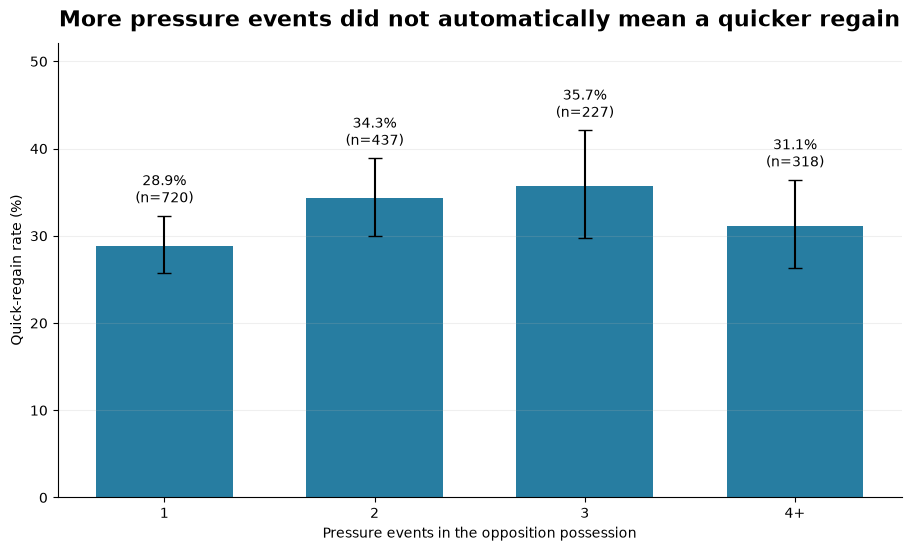

In [10]:
fig, ax = plt.subplots(figsize=(9, 5.4), constrained_layout=True)
x_positions = np.arange(len(intensity_summary))
rates = intensity_summary["regain_rate"].to_numpy()
lower_errors = rates - intensity_summary["ci_low"].to_numpy()
upper_errors = intensity_summary["ci_high"].to_numpy() - rates

bars = ax.bar(
    x_positions,
    rates * 100,
    color=SUCCESS_BLUE,
    width=0.65,
    yerr=np.vstack([lower_errors, upper_errors]) * 100,
    capsize=5,
)

for position, bar, rate, sample_size in zip(
    x_positions,
    bars,
    rates,
    intensity_summary["pressured_possessions"],
):
    ax.text(
        position,
        (rate + upper_errors[position]) * 100 + 1.0,
        f"{rate:.1%}\n(n={sample_size:,})",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_xticks(x_positions, labels=intensity_summary.index)
ax.set_xlabel("Pressure events in the opposition possession")
ax.set_ylabel("Quick-regain rate (%)")
ax.set_title(
    "More pressure events did not automatically mean a quicker regain",
    fontsize=16,
    fontweight="bold",
    pad=12,
)
ax.grid(axis="y", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, max((rates + upper_errors) * 100) + 10)
plt.show()

## 6. Results by pitch third

StatsBomb coordinates run from 0 to 120 along the pitch length. Larger x-values are closer to the opponent's goal for Leverkusen events. These totals provide context for the more detailed heatmaps below.

In [11]:
zone_order = ["Defensive third", "Middle third", "Attacking third"]

zone_summary = (
    analysis_sequences
    .groupby("pressure_zone", observed=False)
    .agg(
        pressured_possessions=("match_id", "size"),
        quick_regains=("regained_within_5s", "sum"),
        shot_sequences=("shot_within_15s", "sum"),
        xg_after_quick_regain=("shot_xg", "sum"),
    )
    .reindex(zone_order)
)
zone_summary["regain_rate"] = (
    zone_summary["quick_regains"] / zone_summary["pressured_possessions"]
)
zone_summary["shot_rate_per_regain"] = (
    zone_summary["shot_sequences"] / zone_summary["quick_regains"]
)

zone_display = zone_summary.copy()
for column in ["pressured_possessions", "quick_regains", "shot_sequences"]:
    zone_display[column] = zone_display[column].map("{:,.0f}".format)
zone_display["xg_after_quick_regain"] = zone_display["xg_after_quick_regain"].map(
    "{:.2f}".format
)
for column in ["regain_rate", "shot_rate_per_regain"]:
    zone_display[column] = zone_display[column].map("{:.1%}".format)

zone_display

,pressured_possessions,quick_regains,shot_sequences,xg_after_quick_regain,regain_rate,shot_rate_per_regain
pressure_zone,,,,,,
Defensive third,561,173,9,1.92,30.8%,5.2%
Middle third,687,228,18,1.87,33.2%,7.9%
Attacking third,454,137,19,4.49,30.2%,13.9%


## 7. StatsBomb counterpress flag

The provider's `counterpress` flag describes an individual event and is not the same as the possession-based quick-regain definition used here. The comparison below is included as a definition check.

In [12]:
counterpress_summary = (
    analysis_sequences
    .assign(
        pressure_type=np.where(
            analysis_sequences["is_counterpress"],
            "Counterpress flagged",
            "Other pressure",
        )
    )
    .groupby("pressure_type")
    .agg(
        pressured_possessions=("match_id", "size"),
        quick_regains=("regained_within_5s", "sum"),
        shot_sequences=("shot_within_15s", "sum"),
    )
)
counterpress_summary["regain_rate"] = (
    counterpress_summary["quick_regains"]
    / counterpress_summary["pressured_possessions"]
)
counterpress_summary["shot_rate_per_regain"] = (
    counterpress_summary["shot_sequences"]
    / counterpress_summary["quick_regains"]
)

counterpress_display = counterpress_summary.copy()
for column in ["pressured_possessions", "quick_regains", "shot_sequences"]:
    counterpress_display[column] = counterpress_display[column].map("{:,.0f}".format)
for column in ["regain_rate", "shot_rate_per_regain"]:
    counterpress_display[column] = counterpress_display[column].map("{:.1%}".format)

counterpress_display

,pressured_possessions,quick_regains,shot_sequences,regain_rate,shot_rate_per_regain
pressure_type,,,,,
Counterpress flagged,260,57,3,21.9%,5.3%
Other pressure,"1,442",481,43,33.4%,8.9%


## 8. Pressure-location heatmaps

The three heatmaps show pressure-sequence volume, quick-regain rate and shot rate after a quick regain. Rates are used so that high-volume areas do not automatically appear more effective.

Cells with small samples are hidden (`n < 25` pressured possessions for regain rate and `n < 10` quick regains for shot rate).

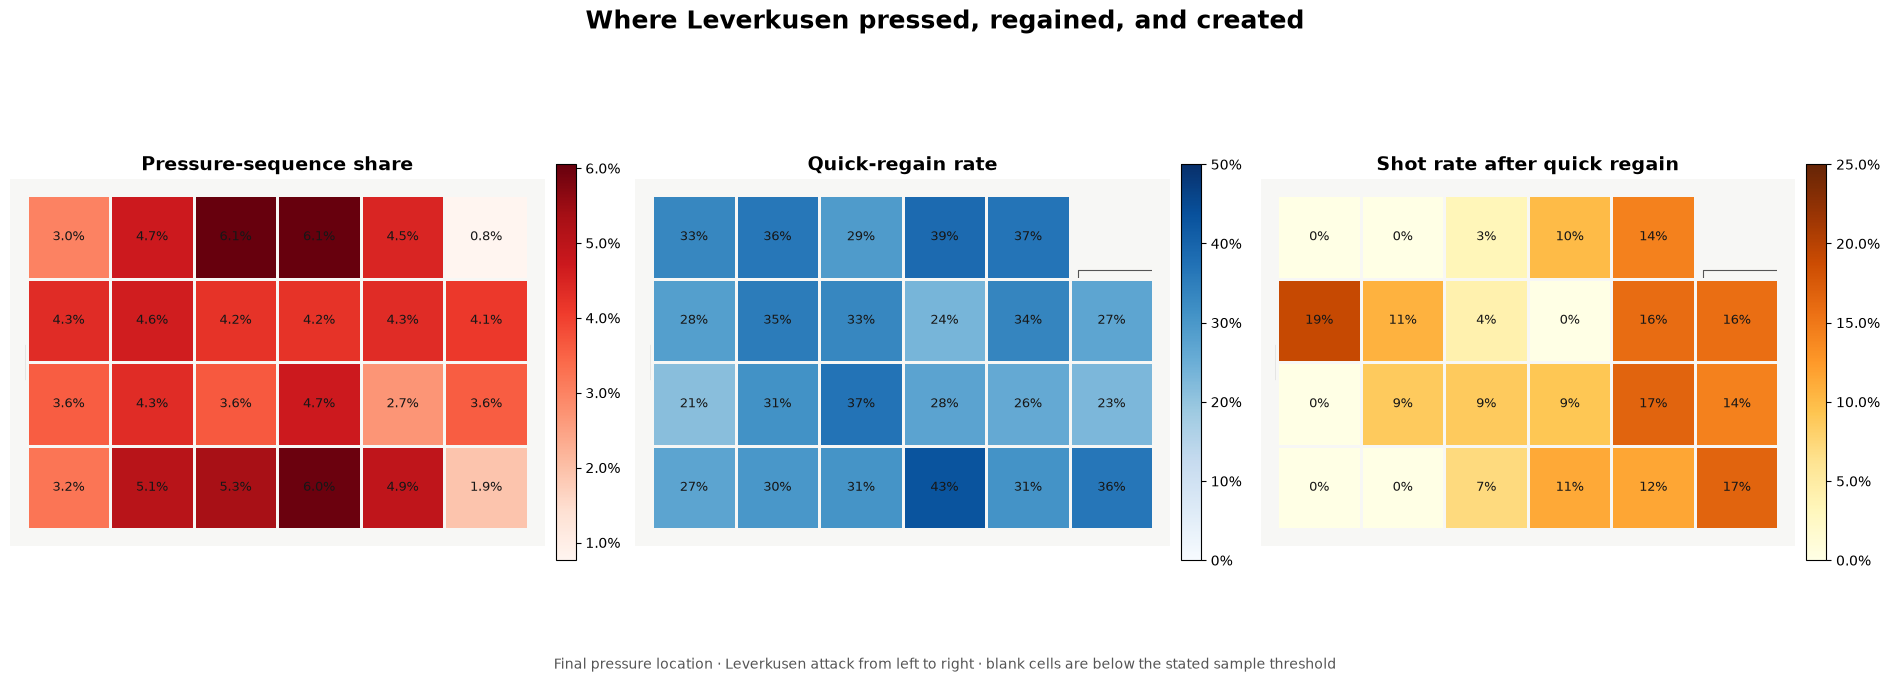

In [13]:
HEATMAP_BINS = (6, 4)
MIN_PRESSURES_PER_BIN = 25
MIN_REGAINS_PER_BIN = 10

heat_pitch = Pitch(
    pitch_type="statsbomb",
    pitch_color="#f7f7f5",
    line_color="#555555",
    linewidth=0.8,
)
fig, axes = heat_pitch.draw(nrows=1, ncols=3, figsize=(19, 6.4))

# 1) Share of all fully observed pressured possessions.
volume_heatmap = heat_pitch.bin_statistic(
    analysis_sequences["pressure_x"],
    analysis_sequences["pressure_y"],
    statistic="count",
    bins=HEATMAP_BINS,
    normalize=True,
)
volume_mesh = heat_pitch.heatmap(
    volume_heatmap,
    ax=axes[0],
    cmap="Reds",
    edgecolors="#f7f7f5",
    linewidth=1,
)
heat_pitch.label_heatmap(
    volume_heatmap,
    ax=axes[0],
    str_format="{:.1%}",
    fontsize=9,
    color=LEVERKUSEN_DARK,
)
axes[0].set_title("Pressure-sequence share", fontsize=14, fontweight="bold")
fig.colorbar(
    volume_mesh,
    ax=axes[0],
    fraction=0.035,
    pad=0.02,
    format=PercentFormatter(xmax=1),
)

# 2) Quick-regain rate, with low-sample cells hidden.
pressure_counts = heat_pitch.bin_statistic(
    analysis_sequences["pressure_x"],
    analysis_sequences["pressure_y"],
    statistic="count",
    bins=HEATMAP_BINS,
)
regain_rate_heatmap = heat_pitch.bin_statistic(
    analysis_sequences["pressure_x"],
    analysis_sequences["pressure_y"],
    values=analysis_sequences["regained_within_5s"].astype(int),
    statistic="mean",
    bins=HEATMAP_BINS,
)
regain_rate_heatmap["statistic"] = np.where(
    pressure_counts["statistic"] >= MIN_PRESSURES_PER_BIN,
    regain_rate_heatmap["statistic"],
    np.nan,
)
regain_mesh = heat_pitch.heatmap(
    regain_rate_heatmap,
    ax=axes[1],
    cmap="Blues",
    edgecolors="#f7f7f5",
    linewidth=1,
    vmin=0,
    vmax=0.5,
)
heat_pitch.label_heatmap(
    regain_rate_heatmap,
    ax=axes[1],
    str_format="{:.0%}",
    fontsize=9,
    color=LEVERKUSEN_DARK,
    exclude_nan=True,
)
axes[1].set_title("Quick-regain rate", fontsize=14, fontweight="bold")
fig.colorbar(
    regain_mesh,
    ax=axes[1],
    fraction=0.035,
    pad=0.02,
    format=PercentFormatter(xmax=1),
)

# 3) Shot rate among quick regains, again hiding sparse cells.
quick_regain_sequences = analysis_sequences.loc[
    analysis_sequences["regained_within_5s"]
]
regain_counts = heat_pitch.bin_statistic(
    quick_regain_sequences["pressure_x"],
    quick_regain_sequences["pressure_y"],
    statistic="count",
    bins=HEATMAP_BINS,
)
shot_rate_heatmap = heat_pitch.bin_statistic(
    quick_regain_sequences["pressure_x"],
    quick_regain_sequences["pressure_y"],
    values=quick_regain_sequences["shot_within_15s"].astype(int),
    statistic="mean",
    bins=HEATMAP_BINS,
)
shot_rate_heatmap["statistic"] = np.where(
    regain_counts["statistic"] >= MIN_REGAINS_PER_BIN,
    shot_rate_heatmap["statistic"],
    np.nan,
)
shot_mesh = heat_pitch.heatmap(
    shot_rate_heatmap,
    ax=axes[2],
    cmap="YlOrBr",
    edgecolors="#f7f7f5",
    linewidth=1,
    vmin=0,
    vmax=0.25,
)
heat_pitch.label_heatmap(
    shot_rate_heatmap,
    ax=axes[2],
    str_format="{:.0%}",
    fontsize=9,
    color=LEVERKUSEN_DARK,
    exclude_nan=True,
)
axes[2].set_title("Shot rate after quick regain", fontsize=14, fontweight="bold")
fig.colorbar(
    shot_mesh,
    ax=axes[2],
    fraction=0.035,
    pad=0.02,
    format=PercentFormatter(xmax=1),
)

fig.suptitle(
    "Where Leverkusen pressed, regained, and created",
    fontsize=18,
    fontweight="bold",
    y=1.02,
)
fig.text(
    0.5,
    -0.01,
    "Final pressure location · Leverkusen attack from left to right · blank cells are below the stated sample threshold",
    ha="center",
    fontsize=10,
    color="#555555",
)
plt.show()

## 9. Match phase

The heatmap checks whether quick-regain rates changed by match period and pressure location. Each cell includes its sample size.

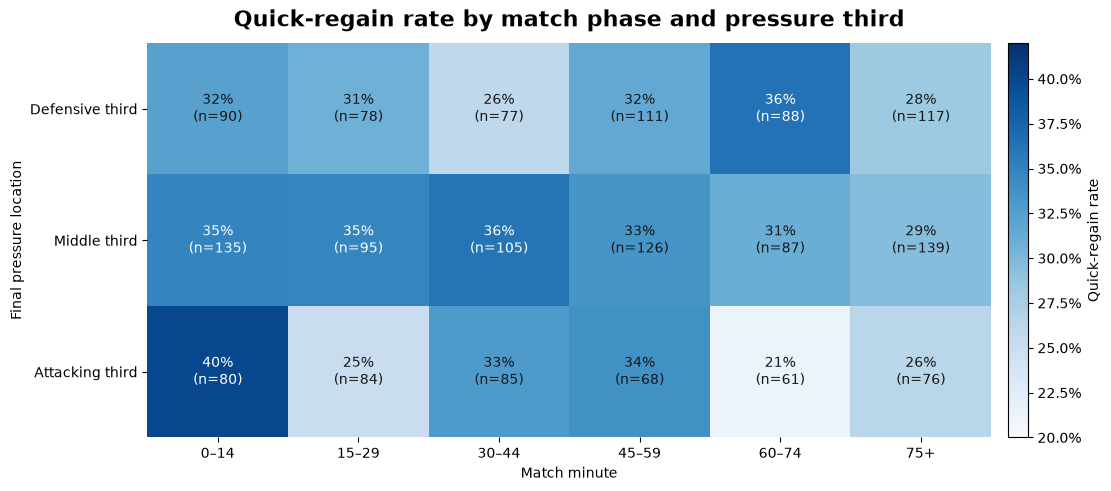

In [14]:
phase_labels = ["0–14", "15–29", "30–44", "45–59", "60–74", "75+"]
analysis_sequences["match_phase"] = pd.cut(
    analysis_sequences["pressure_minute"],
    bins=[0, 15, 30, 45, 60, 75, np.inf],
    labels=phase_labels,
    right=False,
    include_lowest=True,
)

phase_zone_summary = (
    analysis_sequences
    .groupby(["pressure_zone", "match_phase"], observed=False)
    .agg(
        pressured_possessions=("match_id", "size"),
        regain_rate=("regained_within_5s", "mean"),
        shot_rate=("shot_within_15s", "mean"),
    )
)

phase_rate_matrix = (
    phase_zone_summary["regain_rate"]
    .unstack("match_phase")
    .reindex(index=zone_order, columns=phase_labels)
)
phase_count_matrix = (
    phase_zone_summary["pressured_possessions"]
    .unstack("match_phase")
    .reindex(index=zone_order, columns=phase_labels)
)

fig, ax = plt.subplots(figsize=(11, 4.8), constrained_layout=True)
image = ax.imshow(
    phase_rate_matrix.to_numpy(dtype=float),
    cmap="Blues",
    vmin=0.20,
    vmax=0.42,
    aspect="auto",
)

ax.set_xticks(range(len(phase_labels)), labels=phase_labels)
ax.set_yticks(range(len(zone_order)), labels=zone_order)
ax.set_xlabel("Match minute")
ax.set_ylabel("Final pressure location")
ax.set_title(
    "Quick-regain rate by match phase and pressure third",
    fontsize=16,
    fontweight="bold",
    pad=12,
)

for row in range(len(zone_order)):
    for column in range(len(phase_labels)):
        rate = phase_rate_matrix.iloc[row, column]
        count = phase_count_matrix.iloc[row, column]
        label_color = "white" if rate >= 0.34 else LEVERKUSEN_DARK
        ax.text(
            column,
            row,
            f"{rate:.0%}\n(n={count:.0f})",
            ha="center",
            va="center",
            fontsize=10,
            color=label_color,
        )

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.03,
    pad=0.02,
    format=PercentFormatter(xmax=1),
)
colorbar.set_label("Quick-regain rate")
ax.spines[:].set_visible(False)
plt.show()

## 10. Match-to-match variation

The table ranks fixtures by xG created within 15 seconds of a quick regain. It is descriptive and may reflect opponent style, game state or a small number of high-quality chances.

In [15]:
match_context = team_matches.assign(
    opponent=np.where(
        team_matches["home_team_name"].eq(TEAM),
        team_matches["away_team_name"],
        team_matches["home_team_name"],
    ),
    venue=np.where(team_matches["home_team_name"].eq(TEAM), "Home", "Away"),
)[["match_id", "match_date", "opponent", "venue"]]

match_summary = (
    analysis_sequences
    .groupby("match_id")
    .agg(
        pressured_possessions=("match_id", "size"),
        quick_regains=("regained_within_5s", "sum"),
        shot_sequences=("shot_within_15s", "sum"),
        shots=("shot_count", "sum"),
        xg_after_quick_regain=("shot_xg", "sum"),
        goals=("goal_after_regain", "sum"),
    )
    .reset_index()
    .merge(match_context, on="match_id", how="left", validate="one_to_one")
)
match_summary["regain_rate"] = (
    match_summary["quick_regains"] / match_summary["pressured_possessions"]
)

top_match_display = (
    match_summary
    .sort_values(
        ["xg_after_quick_regain", "shot_sequences"],
        ascending=False,
    )
    .head(10)
    [[
        "match_date",
        "opponent",
        "venue",
        "pressured_possessions",
        "regain_rate",
        "shot_sequences",
        "shots",
        "xg_after_quick_regain",
        "goals",
    ]]
    .copy()
)
top_match_display["match_date"] = pd.to_datetime(
    top_match_display["match_date"]
).dt.strftime("%Y-%m-%d")
top_match_display["regain_rate"] = top_match_display["regain_rate"].map(
    "{:.1%}".format
)
top_match_display["xg_after_quick_regain"] = top_match_display[
    "xg_after_quick_regain"
].map("{:.2f}".format)

top_match_display

,match_date,opponent,venue,pressured_possessions,regain_rate,shot_sequences,shots,xg_after_quick_regain,goals
32,2024-05-12,Bochum,Away,35,37.1%,6,6,1.87,1
12,2023-12-03,Borussia Dortmund,Home,39,35.9%,1,1,0.94,1
33,2024-05-18,Augsburg,Home,43,32.6%,1,1,0.75,1
10,2023-11-12,Union Berlin,Home,54,42.6%,4,4,0.73,0
2,2023-09-02,Darmstadt 98,Home,35,31.4%,1,2,0.68,0
19,2024-02-03,Darmstadt 98,Away,50,38.0%,2,2,0.58,0
6,2023-10-08,FC Köln,Home,50,30.0%,3,3,0.39,0
28,2024-04-14,Werder Bremen,Home,63,39.7%,2,2,0.31,1
9,2023-11-04,Hoffenheim,Away,66,34.8%,3,3,0.27,0
4,2023-09-24,FC Heidenheim,Home,51,31.4%,2,2,0.26,0


## 11. Summary

The final cell collects the main results from the calculated tables.

In [16]:
best_regain_zone = zone_summary["regain_rate"].idxmax()
quick_regain_shots = int(analysis_sequences["shot_count"].sum())
quick_regain_xg = analysis_sequences["shot_xg"].sum()
top_five_xg_share = (
    match_summary.nlargest(5, "xg_after_quick_regain")["xg_after_quick_regain"].sum()
    / quick_regain_xg
)
box_result = matched_results.loc["Reached penalty area within 15s"]
shot_result = matched_results.loc["Shot within 15s"]
xg_result = matched_results.loc["xG within 15s"]
best_intensity = intensity_summary["regain_rate"].idxmax()
weakest_intensity = intensity_summary["regain_rate"].idxmin()
best_intensity_rate = intensity_summary.loc[best_intensity, "regain_rate"]
weakest_intensity_rate = intensity_summary.loc[weakest_intensity, "regain_rate"]

# Summarise the wider middle-third area rather than one heatmap cell.
# This region is the middle third (x=40–80) in the two outer 20-metre channels.
wide_middle_mask = (
    analysis_sequences["pressure_x"].between(40, 80, inclusive="left")
    & (
        analysis_sequences["pressure_y"].lt(20)
        | analysis_sequences["pressure_y"].ge(60)
    )
)
wide_middle_share = wide_middle_mask.mean()
wide_middle_regain_rate = analysis_sequences.loc[
    wide_middle_mask, "regained_within_5s"
].mean()
elsewhere_regain_rate = analysis_sequences.loc[
    ~wide_middle_mask, "regained_within_5s"
].mean()
wide_middle_pitch_area_share = (40 * 40) / (120 * 80)

opening_attacking_rate = phase_rate_matrix.loc["Attacking third", "0–14"]
opening_attacking_count = phase_count_matrix.loc["Attacking third", "0–14"]
later_attacking_rate = phase_rate_matrix.loc["Attacking third", "60–74"]
later_attacking_count = phase_count_matrix.loc["Attacking third", "60–74"]

summary_text = f"""
- **Season:** Leverkusen regained the ball within {REGAIN_WINDOW_SECONDS} seconds after **{successful_regains:,} of {total_sequences:,} pressured possessions ({successful_regains / total_sequences:.1%})**. **{shot_sequences} quick regains ({shot_sequences / successful_regains:.1%})** produced a shot within {SHOT_WINDOW_SECONDS} seconds.
- **Location-matched comparison:** penalty-area reach was **{box_result['observed']:.1%} versus {box_result['matched_expected']:.1%}**. Shot probability was **{shot_result['observed']:.1%} versus {shot_result['matched_expected']:.1%}**, while xG was **{xg_result['observed'] * 100:.2f} versus {xg_result['matched_expected'] * 100:.2f} per 100 possessions**.
- **Pressure count:** possessions containing two or three pressure events had higher raw regain rates than single-pressure possessions, but four-plus pressures did not continue that increase.
- **Spatial and match variation:** the wide channels of the middle third contained **{wide_middle_share:.1%}** of final pressure locations and had a **{wide_middle_regain_rate:.1%}** regain rate. The five highest-xG fixtures supplied **{top_five_xg_share:.1%}** of all quick-regain xG.
- **Conclusion:** the point estimates suggest better shooting outcomes after quick regains, but the uplift intervals include zero. The evidence is descriptive and does not establish that pressure caused the turnover or the later chance.
"""

display(Markdown(summary_text.strip()))


- **Season:** Leverkusen regained the ball within 5 seconds after **538 of 1,702 pressured possessions (31.6%)**. **46 quick regains (8.6%)** produced a shot within 15 seconds.
- **Location-matched comparison:** penalty-area reach was **15.3% versus 14.9%**. Shot probability was **6.7% versus 5.0%**, while xG was **1.22 versus 0.65 per 100 possessions**.
- **Pressure count:** possessions containing two or three pressure events had higher raw regain rates than single-pressure possessions, but four-plus pressures did not continue that increase.
- **Spatial and match variation:** the wide channels of the middle third contained **23.4%** of final pressure locations and had a **35.7%** regain rate. The five highest-xG fixtures supplied **60.0%** of all quick-regain xG.
- **Conclusion:** the point estimates suggest better shooting outcomes after quick regains, but the uplift intervals include zero. The evidence is descriptive and does not establish that pressure caused the turnover or the later chance.

## Limitations

- Event data does not capture the full off-ball team shape available from tracking data.
- A quick regain following a recorded pressure does not prove that the pressure caused the turnover.
- Using one row per possession prevents double-counting but gives less attention to earlier players in a multi-pressure sequence.
- Location matching controls only a coarse starting area, not score state, opponent strength, player availability or opponent shape.
- The bootstrap treats the matched baseline rates as fixed, so its intervals are descriptive rather than causal.
- The results describe Leverkusen's 2023/24 Bundesliga season and should not automatically be generalised to other teams or competitions.

Data source: [StatsBomb Open Data](https://github.com/statsbomb/open-data).